
### Target: Strain ###

Ridge → MSE: 0.0118, R²: 0.9965, Coefs: [1.96653466 2.958031   4.92160153]


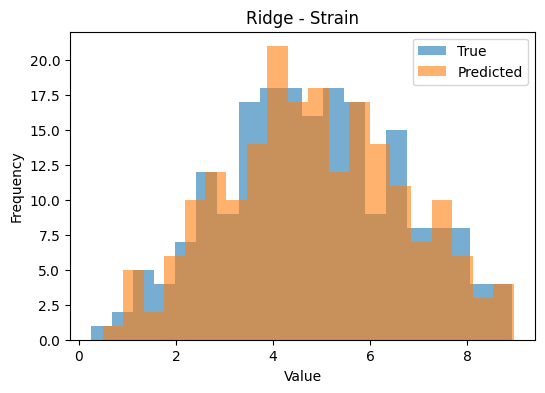

Lasso → MSE: 0.0156, R²: 0.9954, Coefs: [1.8757854  2.8862666  4.87681398]


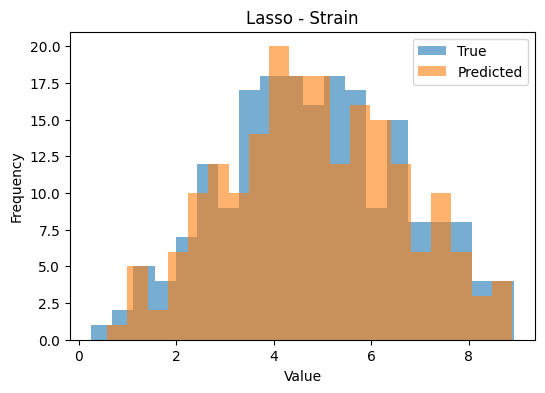

ElasticNet → MSE: 0.0289, R²: 0.9915, Coefs: [1.82611542 2.78546338 4.66223197]


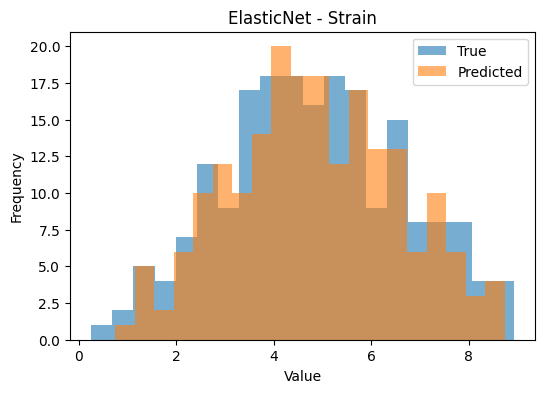


### Target: Temperature ###

Ridge → MSE: 0.0112, R²: 0.9948, Coefs: [1.48499607 2.47427741 3.95170336]


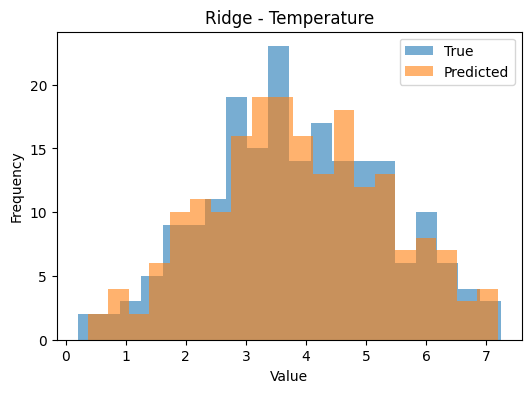

Lasso → MSE: 0.0132, R²: 0.9939, Coefs: [1.38700764 2.3956805  3.89271094]


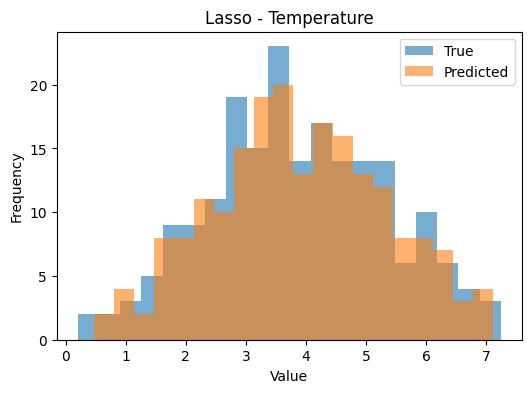

ElasticNet → MSE: 0.0200, R²: 0.9907, Coefs: [1.3650625  2.32111159 3.73258992]


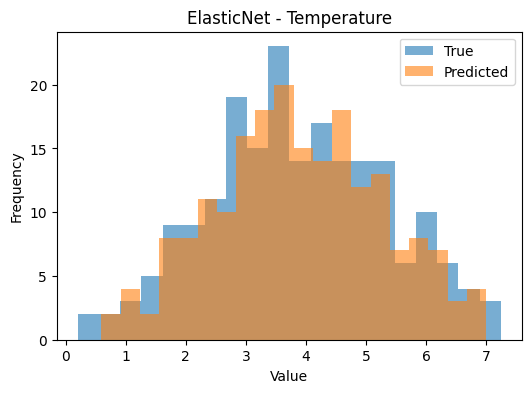

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ------------------------------
# Load your dataset
# ------------------------------
# Replace with your actual CSV path
df = pd.read_csv("fbg_sensor_strain_temperature_data.csv")

# Features and targets
X = df[["FBG1", "FBG2", "FBG3"]].values
targets = {
    
    "Strain": df["Strain"].values,
    "Temperature": df["Temperature"].values
}

# ------------------------------
# Train models and plot histograms
# ------------------------------
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),   # alpha may need tuning
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5)
}

results = {}

for target_name, y in targets.items():
    print(f"\n### Target: {target_name} ###\n")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[(target_name, model_name)] = (mse, r2, model.coef_)
        
        print(f"{model_name} → MSE: {mse:.4f}, R²: {r2:.4f}, Coefs: {model.coef_}")
        
        # ------------------------------
        # Histogram plot (true vs predicted)
        # ------------------------------
        plt.figure(figsize=(6,4))
        plt.hist(y_test, bins=20, alpha=0.6, label="True")
        plt.hist(y_pred, bins=20, alpha=0.6, label="Predicted")
        plt.title(f"{model_name} - {target_name}")
        plt.xlabel("Value")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()


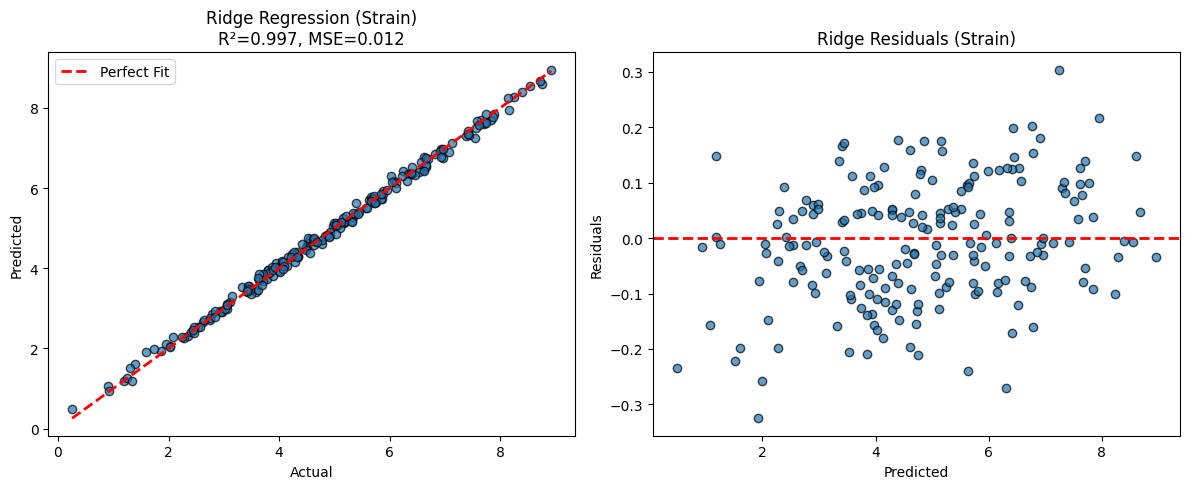

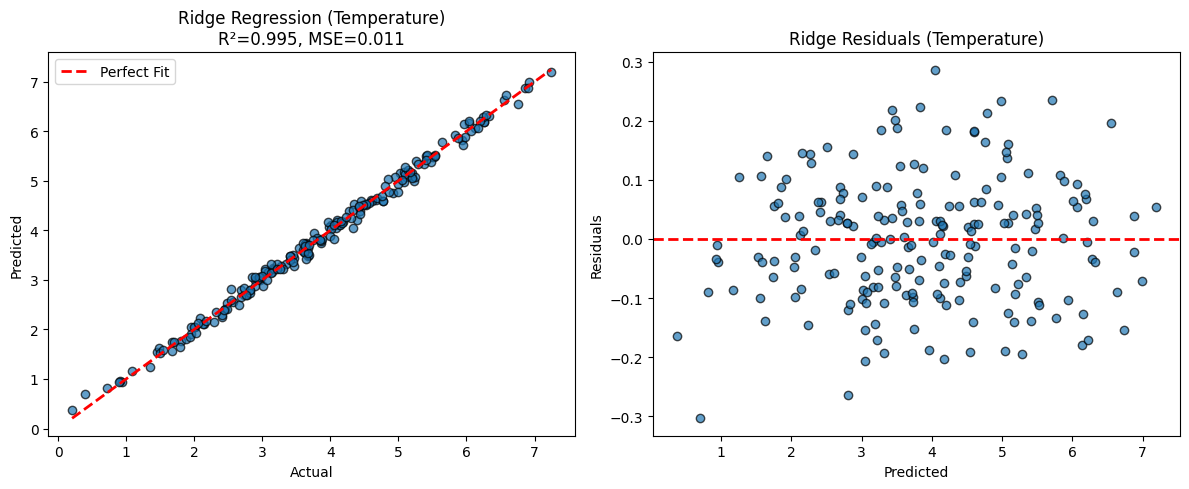

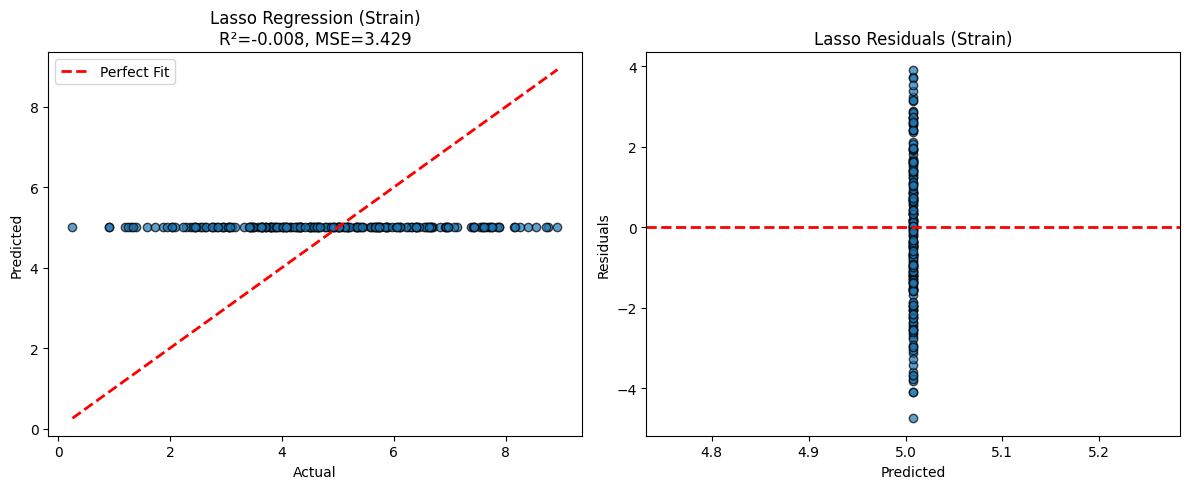

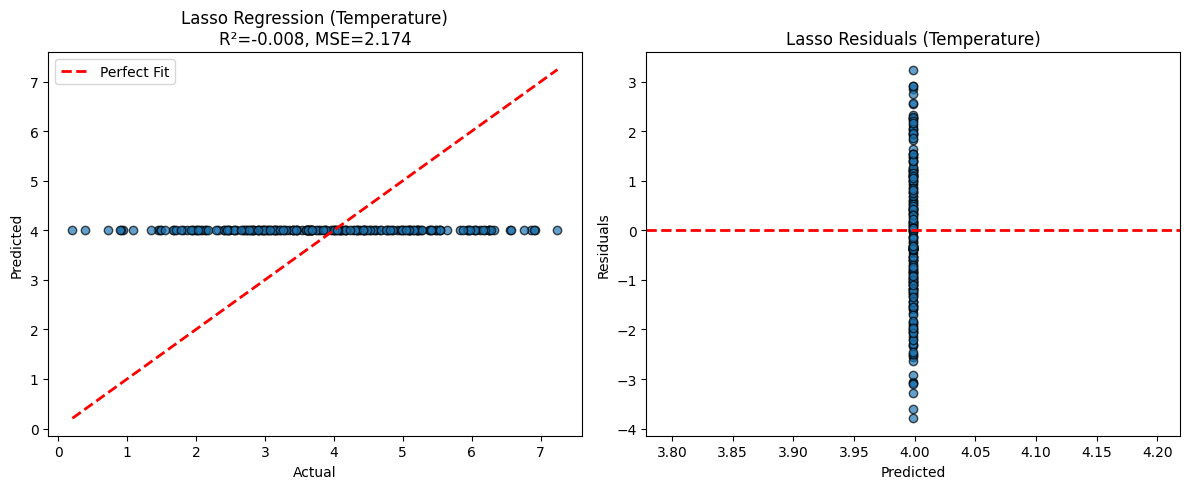

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Assume your dataframe is df with columns: ["FBG1", "FBG2", "FBG3", "strain", "temperature"]

X = df[["FBG1", "FBG2", "FBG3"]].values

# --- Train/test split for strain ---
y_strain = df["Strain"].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y_strain, test_size=0.2, random_state=42)

# --- Train/test split for temp ---
y_temp = df["Temperature"].values
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X, y_temp, test_size=0.2, random_state=42)

def train_and_plot(Model, name, X_train, X_test, y_train, y_test, target):
    model = Model(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # --- Plot Predictions vs Actual ---
    plt.figure(figsize=(12,5))

    # Left: predictions vs actual
    plt.subplot(1,2,1)
    plt.scatter(y_test, y_pred, alpha=0.7, edgecolor="k")
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             "r--", lw=2, label="Perfect Fit")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name} Regression ({target})\nR²={r2:.3f}, MSE={mse:.3f}")
    plt.legend()

    # Right: residuals
    plt.subplot(1,2,2)
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals, alpha=0.7, edgecolor="k")
    plt.axhline(0, color="r", linestyle="--", lw=2)
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title(f"{name} Residuals ({target})")

    plt.tight_layout()
    plt.show()

# --- Run for Ridge and Lasso on strain and temp ---
for Model, name in [(Ridge, "Ridge"), (Lasso, "Lasso")]:
    train_and_plot(Model, name, X_train_s, X_test_s, y_train_s, y_test_s, target="Strain")
    train_and_plot(Model, name, X_train_t, X_test_t, y_train_t, y_test_t, target="Temperature")


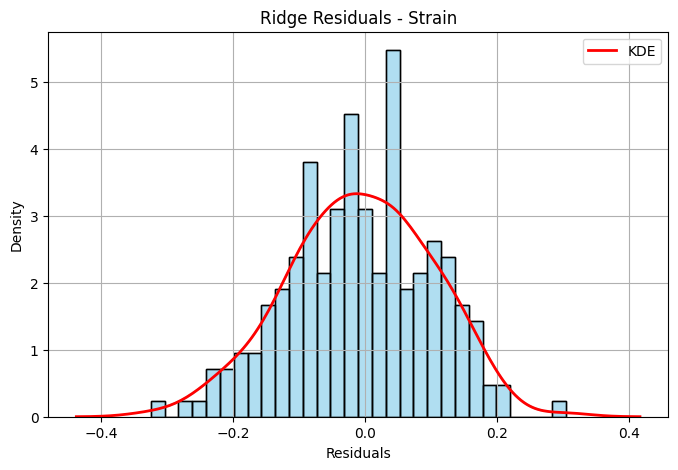

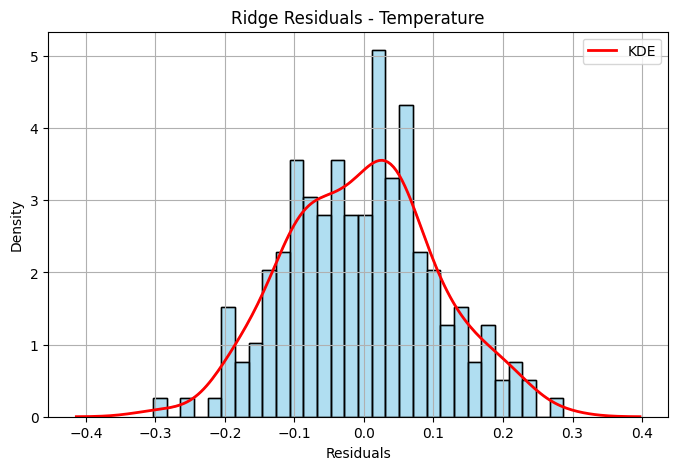

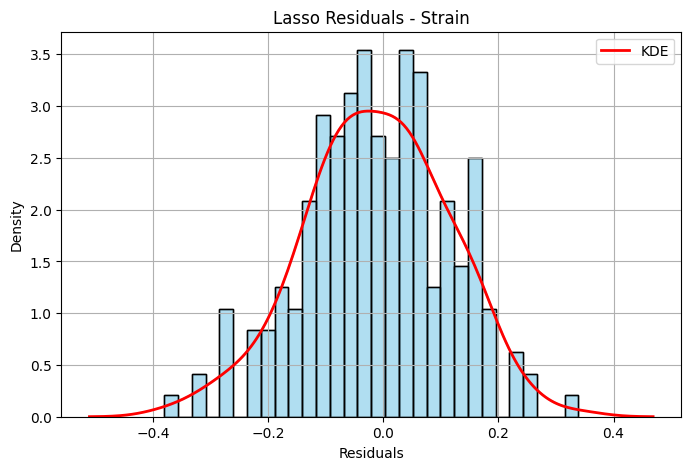

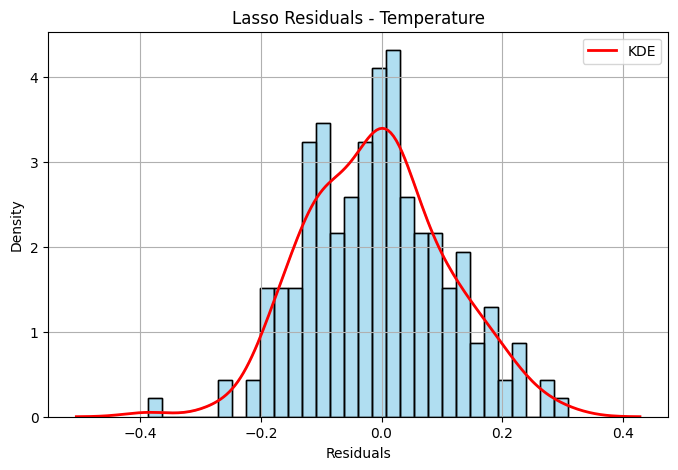

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Assuming df contains columns: 'FBG1', 'FBG2', 'FBG3', 'Strain', 'Temp'
X = df[['FBG1', 'FBG2', 'FBG3']].values
y_strain = df['Strain'].values
y_temp = df['Temperature'].values

# Split into train/test
X_train, X_test, y_strain_train, y_strain_test = train_test_split(X, y_strain, test_size=0.2, random_state=42)
_, _, y_temp_train, y_temp_test = train_test_split(X, y_temp, test_size=0.2, random_state=42)

# Ridge regression for strain
ridge_strain = Ridge(alpha=1.0)
ridge_strain.fit(X_train, y_strain_train)
y_strain_pred_ridge = ridge_strain.predict(X_test)
residuals_ridge_strain = y_strain_test - y_strain_pred_ridge

# Ridge regression for temp
ridge_temp = Ridge(alpha=1.0)
ridge_temp.fit(X_train, y_temp_train)
y_temp_pred_ridge = ridge_temp.predict(X_test)
residuals_ridge_temp = y_temp_test - y_temp_pred_ridge

# Lasso regression for strain
lasso_strain = Lasso(alpha=0.01)
lasso_strain.fit(X_train, y_strain_train)
y_strain_pred_lasso = lasso_strain.predict(X_test)
residuals_lasso_strain = y_strain_test - y_strain_pred_lasso

# Lasso regression for temp
lasso_temp = Lasso(alpha=0.01)
lasso_temp.fit(X_train, y_temp_train)
y_temp_pred_lasso = lasso_temp.predict(X_test)
residuals_lasso_temp = y_temp_test - y_temp_pred_lasso

# ---------- Plotting ----------
def plot_residuals(residuals, title):
    plt.figure(figsize=(8,5))
    sns.histplot(residuals, kde=True, stat="density", bins=30, color="skyblue", edgecolor="black")
    sns.kdeplot(residuals, color="red", lw=2, label="KDE")
    sns.histplot(residuals, bins=30, stat="density", color="skyblue", alpha=0.3)
    plt.title(title)
    plt.xlabel("Residuals")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

# Ridge plots
plot_residuals(residuals_ridge_strain, "Ridge Residuals - Strain")
plot_residuals(residuals_ridge_temp, "Ridge Residuals - Temperature")

# Lasso plots
plot_residuals(residuals_lasso_strain, "Lasso Residuals - Strain")
plot_residuals(residuals_lasso_temp, "Lasso Residuals - Temperature")


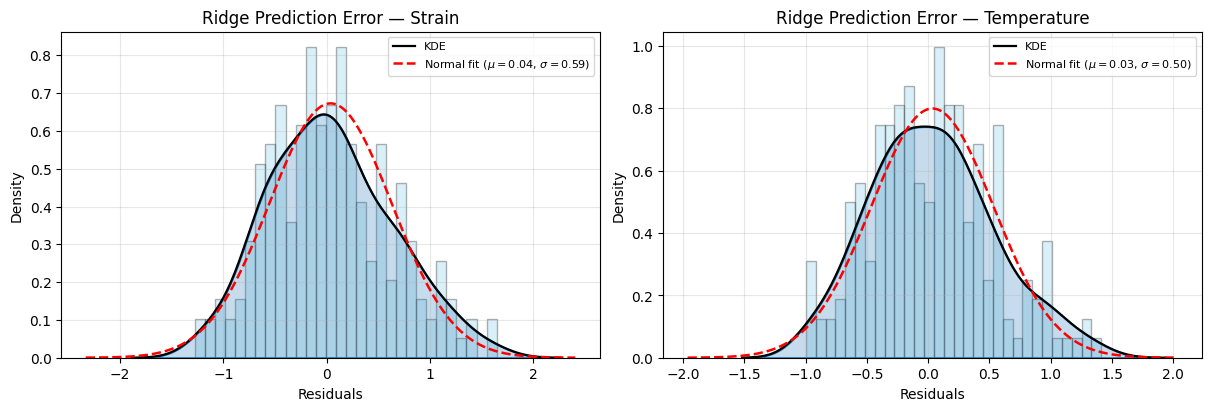

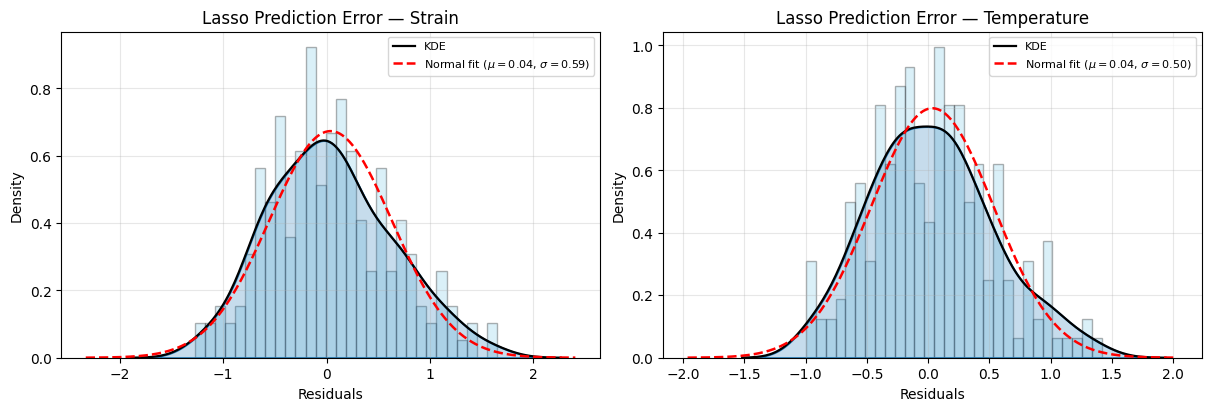

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

def plot_residual_panel(residuals_strain, residuals_temp, title_prefix, savefile=None):
    """Make a 1×2 panel: (Strain residuals, Temperature residuals)
       with histogram (density), filled KDE, and fitted normal curve."""

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    def _one(ax, data, subtitle):
        data = np.asarray(data)

        # Histogram (density)
        ax.hist(data, bins=30, density=True, alpha=0.3,
                color="skyblue", edgecolor="black")

        # KDE (filled + line)
        sns.kdeplot(data, ax=ax, fill=True, alpha=0.25, linewidth=1.5)
        sns.kdeplot(data, ax=ax, color="black", linewidth=1.6, label="KDE")

        # Fitted normal curve (μ, σ from data)
        mu, sigma = data.mean(), data.std(ddof=0)
        x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
        ax.plot(x, norm.pdf(x, mu, sigma), "r--", linewidth=1.8,
                label=rf"Normal fit ($\mu={mu:.2f}$, $\sigma={sigma:.2f}$)")

        ax.set_title(subtitle, fontsize=12)
        ax.set_xlabel("Residuals")
        ax.set_ylabel("Density")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    _one(axes[0], residuals_strain, f"{title_prefix} — Strain")
    _one(axes[1], residuals_temp,   f"{title_prefix} — Temperature")

    if savefile is None:
        savefile = f"{title_prefix.replace(' ', '_').lower()}_residuals_seperate.png"

    # ✅ Actually save the figure
    plt.savefig(savefile, dpi=300, bbox_inches="tight")
    plt.show()

# --------------------------------------------------
# Example usage
# --------------------------------------------------
# Features
X = df[['FBG1','FBG2','FBG3']].sum(axis=1).values.reshape(-1, 1)

# Targets
y_strain = df['Strain'].values
y_temp   = df['Temperature'].values

# Train/test split
X_train, X_test, y_strain_train, y_strain_test, y_temp_train, y_temp_test = train_test_split(
    X, y_strain, y_temp, test_size=0.2, random_state=42
)

# Ridge models (separate instances!)
ridge_strain = Ridge(alpha=1.0).fit(X_train, y_strain_train)
ridge_temp   = Ridge(alpha=1.0).fit(X_train, y_temp_train)

# Lasso models (separate instances!)
lasso_strain = Lasso(alpha=0.001).fit(X_train, y_strain_train)
lasso_temp   = Lasso(alpha=0.001).fit(X_train, y_temp_train)

# Residuals
residuals_ridge_strain = y_strain_test - ridge_strain.predict(X_test)
residuals_ridge_temp   = y_temp_test   - ridge_temp.predict(X_test)

residuals_lasso_strain = y_strain_test - lasso_strain.predict(X_test)
residuals_lasso_temp   = y_temp_test   - lasso_temp.predict(X_test)

# Panels
plot_residual_panel(residuals_ridge_strain, residuals_ridge_temp,
                    "Ridge Prediction Error", savefile="ridge_panel.png")

plot_residual_panel(residuals_lasso_strain, residuals_lasso_temp,
                    "Lasso Prediction Error", savefile="lasso_panel.png")



In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training metrics
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    # Test metrics
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    # Create a DataFrame row
    results = pd.DataFrame({
        "Model": [model_name],
        "Train_MAE": [mae_train],
        "Train_MSE": [mse_train],
        "Train_RMSE": [rmse_train],
        "Train_R2": [r2_train],
        "Test_MAE": [mae_test],
        "Test_MSE": [mse_test],
        "Test_RMSE": [rmse_test],
        "Test_R2": [r2_test]
    })

    return results


# Example usage
# Suppose you already have a trained model, X_train, y_train, X_test, y_test:
from sklearn.linear_model import Ridge
model1 = Ridge().fit(X_train, y_train)
model2 = Lasso().fit(X_train, y_train)
# Evaluate and collect results
results_df1 = evaluate_model(model1, X_train, y_train, X_test, y_test, "Ridge Regression")
results_df2 = evaluate_model(model2, X_train, y_train, X_test, y_test, "Lasso Regression")
# If you want to test multiple models:
final_results = pd.concat([results_df1, results_df2], ignore_index=True)

# Print nicely
print(final_results.to_string(index=False))


           Model  Train_MAE  Train_MSE  Train_RMSE  Train_R2  Test_MAE  Test_MSE  Test_RMSE   Test_R2
Ridge Regression   0.433983   0.277075    0.526379    0.8698  0.401909  0.250427   0.500427  0.883876
Lasso Regression   1.195600   2.128069    1.458790    0.0000  1.208248  2.173944   1.474430 -0.008063


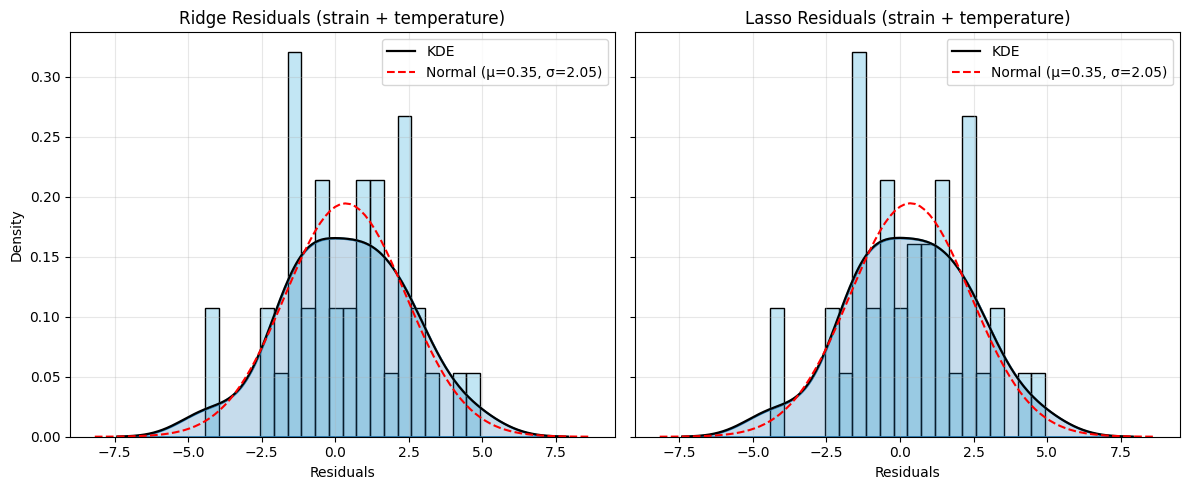

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import norm

# Example dataset (replace with your actual one)
# df = pd.read_csv("your_data.csv")
# X = df[["strain", "temperature"]]
# y = df["target"]

# Simulated data for demo
np.random.seed(0)
X = pd.DataFrame({
    "strain": np.random.normal(0, 1, 200),
    "temperature": np.random.normal(25, 5, 200)
})
y = 3*X["strain"] + 3*X["temperature"] + np.random.normal(0, 2, 200)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge and Lasso models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.01)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Predictions
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

# Residuals
ridge_resid = y_test - ridge_pred
lasso_resid = y_test - lasso_pred



fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, residuals, title in zip(
    axes,
    [ridge_resid, lasso_resid],
    ["Ridge Residuals (strain + temperature)", "Lasso Residuals (strain + temperature)"]
):
    mean, std = np.mean(residuals), np.std(residuals)

    # Histogram + KDE
    sns.histplot(residuals, bins=20, kde=True, stat="density",
                 color="skyblue", edgecolor="black", ax=ax)
    sns.kdeplot(residuals, fill=True, alpha=0.25, linewidth=1.5, ax=ax)
    sns.kdeplot(residuals, color="black", linewidth=1.6, label="KDE", ax=ax)

    # Normal distribution curve
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    ax.plot(x, norm.pdf(x, mean, std), 'r--',
            label=f'Normal (μ={mean:.2f}, σ={std:.2f})')

    ax.set_title(title)
    ax.set_xlabel("Residuals")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ridge_lasso_residuals_subplot_s+t.png", dpi=300, bbox_inches='tight')
plt.show()
# Function to plot histogram with KDE + Normal
# def plot_residuals(residuals, title):
#     mean, std = np.mean(residuals), np.std(residuals)
#     plt.figure(figsize=(7,5))
#     sns.histplot(residuals, bins=20, kde=True, stat="density", color="skyblue", edgecolor="black")
#     sns.kdeplot(residuals, fill=True, alpha=0.25, linewidth=1.5)
#     sns.kdeplot(residuals, color="black", linewidth=1.6, label="KDE")
#     # Normal distribution curve
#     xmin, xmax = plt.xlim()
#     x = np.linspace(xmin, xmax, 100)
#     plt.plot(x, norm.pdf(x, mean, std), 'r--', label=f'Normal (μ={mean:.2f}, σ={std:.2f})')
#     plt.grid(alpha=0.3)
#     plt.title(title)
#     plt.xlabel("Residuals")
#     plt.ylabel("Density")
#     plt.legend()
#     plt.savefig("r&l_s+t.png", dpi=300, bbox_inches='tight')
#     plt.show()

# # Plot for Ridge
# plot_residuals(ridge_resid, "Ridge Residuals (strain + temperature)")

# # Plot for Lasso
# plot_residuals(lasso_resid, "Lasso Residuals (strain + temperature)")


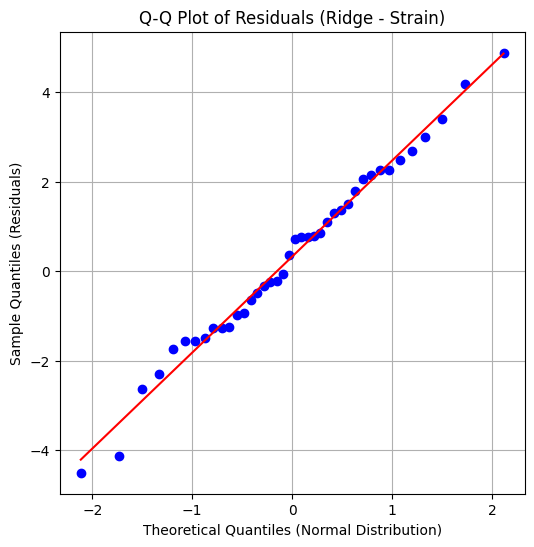

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Example: replace with your actual residuals
# e.g. residuals_ridge_strain, residuals_ridge_temp, residuals_lasso_strain, residuals_lasso_temp
residuals = lasso_resid 

# Q-Q Plot
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)  
plt.title("Q-Q Plot of Residuals (Ridge - Strain)")
plt.xlabel("Theoretical Quantiles (Normal Distribution)")
plt.ylabel("Sample Quantiles (Residuals)")
plt.grid(True)
plt.show()


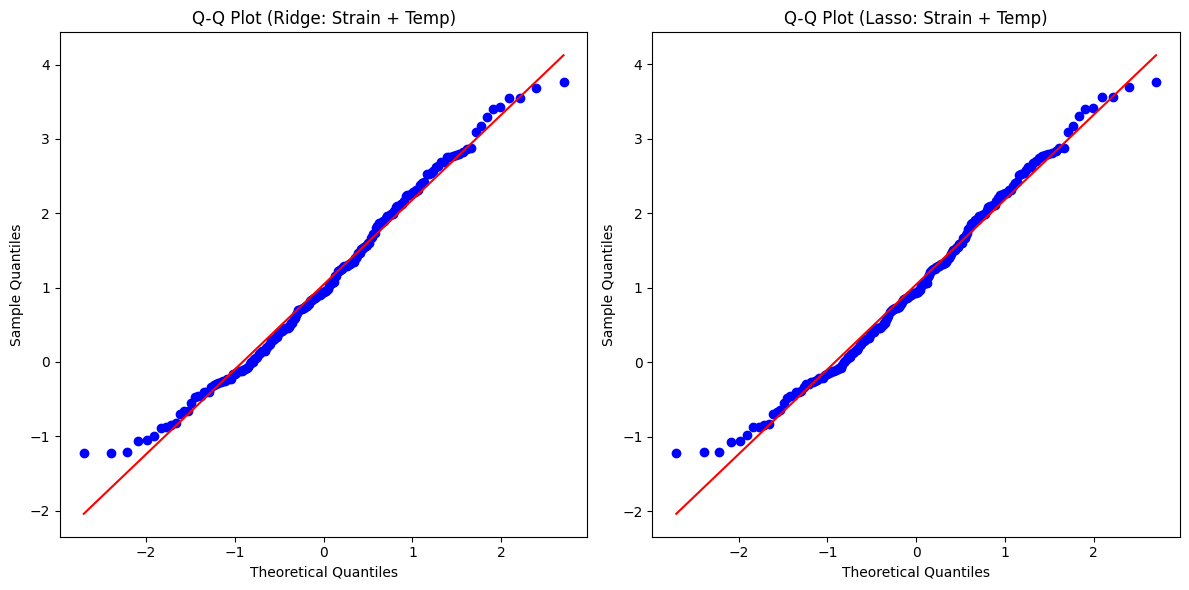

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assuming residuals are NumPy arrays of the same length
# residuals_ridge_strain, residuals_ridge_temp
# residuals_lasso_strain, residuals_lasso_temp

# Combine strain + temp (elementwise addition)
residuals_ridge = residuals_ridge_strain + residuals_ridge_temp
residuals_lasso = residuals_lasso_strain + residuals_lasso_temp

# Q-Q plots
plt.figure(figsize=(12,6))

# Ridge
plt.subplot(1,2,1)
stats.probplot(residuals_ridge, dist="norm", plot=plt)
plt.title("Q-Q Plot (Ridge: Strain + Temp)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

# Lasso
plt.subplot(1,2,2)
stats.probplot(residuals_lasso, dist="norm", plot=plt)
plt.title("Q-Q Plot (Lasso: Strain + Temp)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()
